In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN

from transformers import GPT2Tokenizer, AutoModelForCausalLM

In [2]:
# import tokenizer and the model
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")
#

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [3]:
embeddings = model.transformer.wte.weight.detach().numpy()

# Find the tokens that contain the letter x and have lengths of 4 to 8 without leading space

tokens = []
token_ids = []
for tid in range(tokenizer.vocab_size):
  decoded = tokenizer.decode([tid])
  stripped = decoded.lstrip()
  if 4<= len(stripped) <= 8 and 'x' in stripped:
    tokens.append(tokenizer.decode([tid]))
    token_ids.append(tid)

tokens = np.array(tokens)

print(f'Found {len(tokens)} tokens that contains the letter "x"')
print(f'Tokens with letter "x" and length 4-8:')
print('\n'.join(f'"{t}"' for t in tokens))


Found 514 tokens that contains the letter "x"
Tokens with letter "x" and length 4-8:
" exper"
" expl"
" next"
" expect"
" example"
" exist"
" text"
" exec"
" exact"
" exam"
" except"
" expected"
"ixed"
" execut"
" extra"
" sexual"
" extreme"
" experien"
" exactly"
" complex"
" Texas"
" exerc"
" expand"
" Alex"
" existing"
" explain"
" context"
" express"
" exchange"
"text"
" maximum"
" exercise"
"xual"
" approx"
" taxes"
" Mexico"
" expert"
" Expl"
" fixed"
" explos"
" examples"
" experts"
" explan"
" extent"
" index"
" excited"
" explains"
" explo"
" excess"
" Linux"
" flex"
" exceed"
" extended"
" external"
" exposure"
" exists"
"ixel"
" explore"
" exhib"
" exposed"
" Next"
" mixed"
" exciting"
" extract"
" explicit"
" Exper"
"Text"
" Text"
" Exec"
" exit"
" unex"
"oenix"
"osexual"
" relax"
" extrem"
" taxp"
" extend"
" Galaxy"
" exha"
" expenses"
" Xbox"
"ixture"
"index"
" Phoenix"
" anxiety"
" expanded"
" exch"
" extraord"
"Next"
"flix"
" exclus"
" Marx"
" boxes"
" Express"
" exami

# Gram Matrix

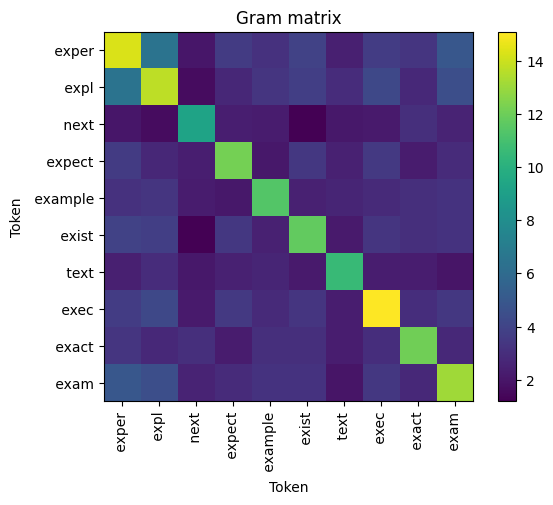

In [4]:
# fig = plt.figure(figsize=(10,5))

token_ids_gramm = np.array(token_ids)[:10]
toks = embeddings[token_ids_gramm]

# Gram matrix
G = toks @ toks.T

plt.imshow(G)
ax = plt.gca()

ax.set_xlabel("Token")
ax.set_ylabel("Token")
ax.set_title("Gram matrix")

# Decode each token separately
labels = [tokenizer.decode([i]) for i in token_ids_gramm]

# Set tick locations and labels
ax.set_xticks(range(len(token_ids_gramm)))
ax.set_yticks(range(len(token_ids_gramm)))

ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)

plt.colorbar()

# plt.tight_layout()
plt.show()


# tSNE on embedding vectors

In [5]:
tsne = TSNE(n_components=2, perplexity=5)
tsne_result = tsne.fit_transform(embeddings[token_ids])

In [6]:
tsne_result.shape

(514, 2)

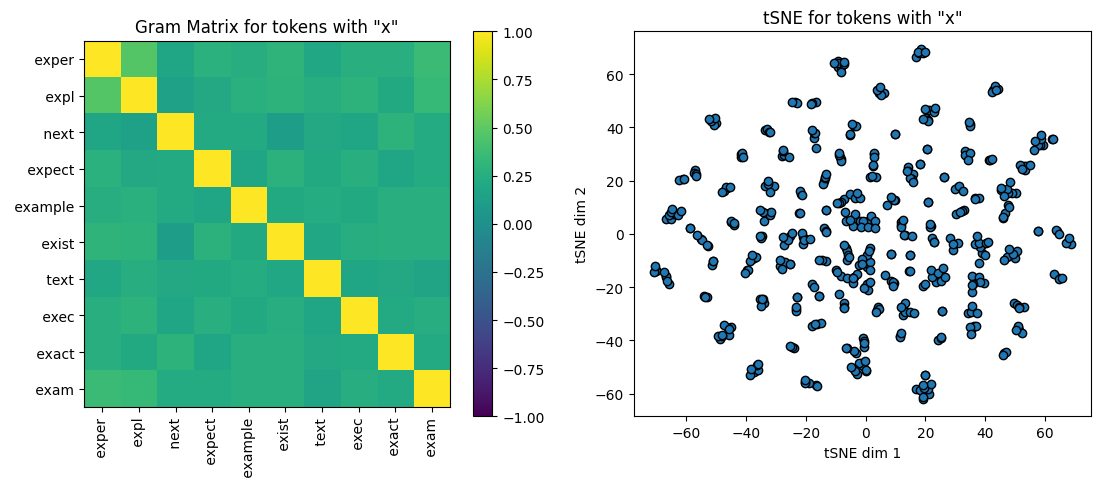

In [7]:
_, axs = plt.subplots(1,2,figsize=(13,5))

nToks = len(token_ids)

toks_norm = toks / np.linalg.norm(toks, axis=1, keepdims=True)
G = toks_norm [:10]@ toks_norm[:10].T

# Gram matrix
im = axs[0].imshow(G, vmin=-1, vmax=1)

axs[0].set_xticks(range(10))
axs[0].set_yticks(range(10))

axs[0].set_xticklabels(
    [tokenizer.decode([token_ids[j]]) for j in range(10)],
    rotation=90
)

axs[0].set_yticklabels(
    [tokenizer.decode([token_ids[j]]) for j in range(10)]
)

axs[0].set_title('Gram Matrix for tokens with "x"')
plt.colorbar(im, ax=axs[0])

# TSNE scatter
axs[1].scatter(tsne_result[:,0], tsne_result[:,1],
               edgecolor="k")

# Label tokens correctly
for i in range(nToks):
    tok_id = token_ids[i]
    label = tokenizer.decode([tok_id])

    if not label.isprintable():
        label = "<CTRL>"

    # axs[1].text(tsne_result[i,0],
    #             tsne_result[i,1],
    #             label,
    #             ha="center")

    axs[1].set_title('tSNE for tokens with "x"')
    axs[1].set_xlabel("tSNE dim 1")
    axs[1].set_ylabel("tSNE dim 2")

plt.show()

# DBSCAN Clustering

In [8]:
tsne_result

array([[-13.927577 ,  19.8209   ],
       [ -7.1689124,  12.960807 ],
       [-41.788685 ,  28.960926 ],
       ...,
       [-15.674938 ,  -9.954328 ],
       [ 46.092724 ,   6.201382 ],
       [ -3.0059829,  15.454734 ]], dtype=float32)

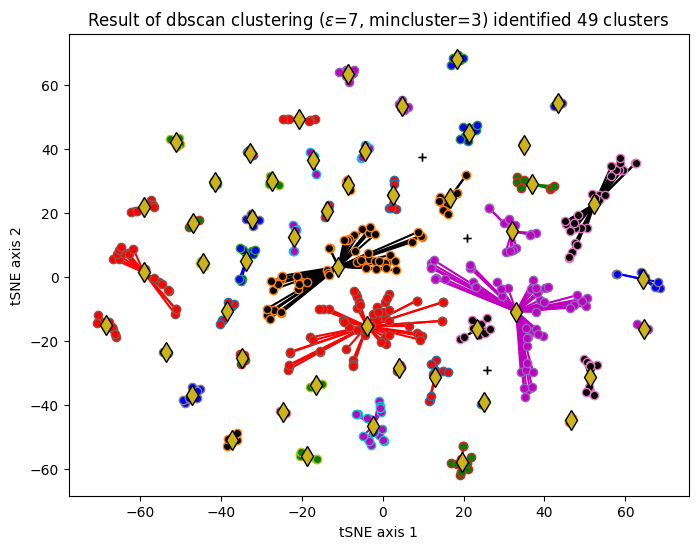

In [27]:
# dbscan
epsilon = 7
min_samples = 3

# dbscan
clustmodel = DBSCAN(eps=epsilon, min_samples=min_samples).fit(tsne_result)

# cluster assignment labels
groupidx = clustmodel.labels_

# number of clusters
nclust = max(groupidx)+1 # +1 for indexing

# calculate the cluster centers
cents = np.zeros((nclust,2))
for ci in range(nclust):
  cents[ci,0] = np.mean(tsne_result[groupidx==ci,0])
  cents[ci,1] = np.mean(tsne_result[groupidx==ci,1])


# draw lines from each data point to the centroids of each cluster
plt.figure(figsize=(8,6))
lineColors = 'rkbgm'

# plot each dot according to its cluster (or lack thereof)
for i in range(len(tsne_result)):
  if groupidx[i]==-1:
    plt.plot(tsne_result[i,0],tsne_result[i,1],'k+')
  else:
    plt.plot([ tsne_result[i,0], cents[groupidx[i],0] ],[ tsne_result[i,1], cents[groupidx[i],1] ],lineColors[groupidx[i] % len(lineColors)])


# now draw the raw data in different colors
for i in range(nclust):
  plt.plot(tsne_result[groupidx==i,0],tsne_result[groupidx==i,1],'o',markerfacecolor=lineColors[i % len(lineColors)])

# and now plot the centroid locations
plt.plot(cents[:,0],cents[:,1],'kd',markerfacecolor=[.8,.7,.1],markersize=10)
plt.gca().set(
    xlabel="tSNE axis 1",
    ylabel="tSNE axis 2",
    title=rf"Result of dbscan clustering ($\epsilon$={epsilon}, mincluster={min_samples}) identified {nclust} clusters"
)

plt.show()

In [23]:
for cidx in range(-1,nclust):

  # find all the tokens in this group
  tokensInGroup = np.where(groupidx==cidx)[0]

  # print them out
  if cidx==-1:
    print(f'\nUngrouped tokens:')
  else:
    print(f'\nTokens in group {cidx}:')
  # print([ ' '.join(tokenizer.decode([t])) for t in tokensInGroup ])
  print([tokenizer.decode([token_ids[t]]) for t in tokensInGroup ])


Ungrouped tokens:
[' Brexit', 'xxxx', 'xxxxxxxx', 'maxwell', ' gmaxwell', 'Brexit']

Tokens in group 0:
[' exper', ' experien', ' Exper', 'Exper', 'exper']

Tokens in group 1:
[' expl', ' extreme', ' expand', ' explain', ' Expl', ' explan', ' extent', ' explains', ' extended', ' explore', ' extrem', ' extend', ' expanded', ' examine', ' examined', ' extends', ' Extreme', 'Expl', ' explored', ' Explorer', ' expans', 'expl', ' Deluxe', ' excav', ' Remix', ' Excel', ' Extended', ' explores', ' excel', ' expands', ' examines', ' exponent', 'extreme', ' Redux', ' extremes', ' unexpl', 'aspx', ' remix', 'Explore', 'Extreme', ' sidx', ' explor', ' explorer', ' Explore', 'roxy', ' exoner', ' exce', 'ixtape', ' Extend', ' Extrem', ' Explain', ' Expand', ' Explan']

Tokens in group 2:
[' next', ' Next', 'Next', 'next']

Tokens in group 3:
[' expect', ' expected', ' expects', ' Expect', 'expected']

Tokens in group 4:
[' example', ' examples', 'Example', ' Example', 'example', ' Examples', ' exe

In [34]:
# Change the parameters of DBSCAN and plot the results
eps_vals = np.arange(1,21)
min_samples_vals = np.arange(1,21)

dbscan_results = np.zeros((len(eps_vals), len(min_samples_vals)))

for i, e in enumerate(eps_vals):
  for j, m in enumerate(min_samples_vals):
    clustmodel = DBSCAN(eps=e, min_samples=m).fit(tsne_result)
    dbscan_results[i,j] = max(clustmodel.labels_) + 1 # Use 0-based indices

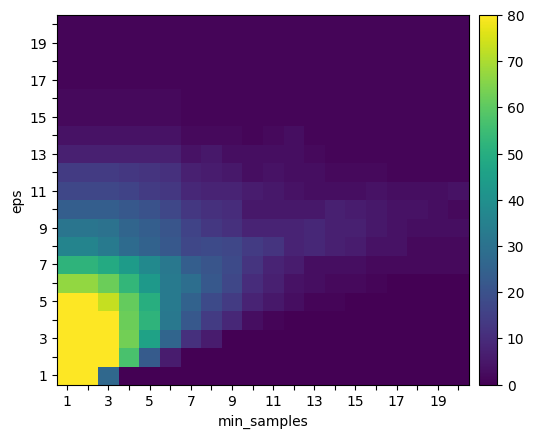

In [71]:
# Visualize the results
# Reverse the dbscan_results array vertically to show eps from max to min on the plot
plt.imshow(dbscan_results, vmin=0, vmax=80, origin='lower', aspect='auto')
plt.colorbar(pad=0.02)

ax = plt.gca()

# Create custom labels for x-axis: all ticks, but only odd-indexed values get labels
x_labels = [str(val) if val % 2 != 0 else '' for val in min_samples_vals]
ax.set_xticks(np.arange(len(min_samples_vals)))
ax.set_xticklabels(x_labels)
plt.xlabel("min_samples")

# Create custom labels for y-axis: all ticks, but only odd-indexed values get labels
y_labels = [str(val) if val % 2 != 0 else '' for val in eps_vals]
ax.set_yticks(np.arange(len(eps_vals)))
ax.set_yticklabels(y_labels)
plt.ylabel("eps")

plt.show()

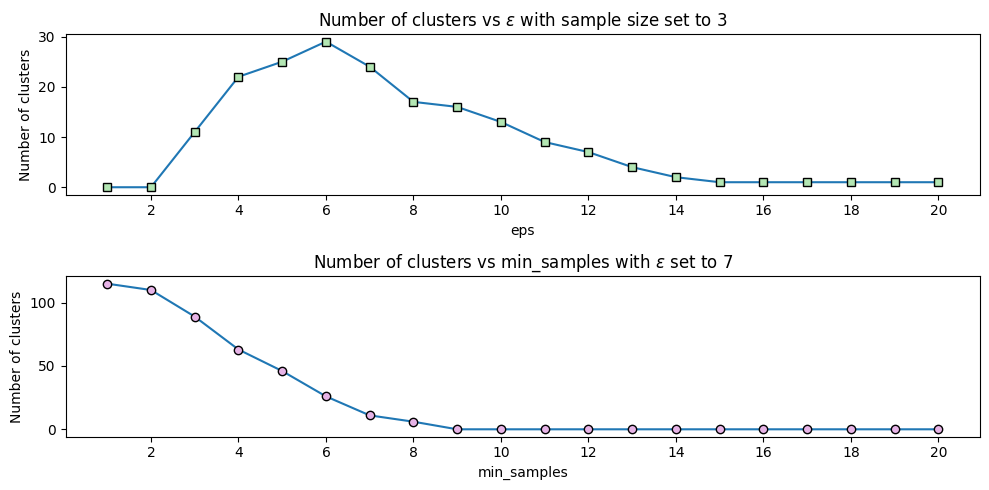

In [63]:
import matplotlib.ticker as ticker

# Visulaize the results first with a fixed sample size  and then with a fixed eps value

eps_fixed = 7
min_cluster_fixed = 3

_, axs = plt.subplots(2,1,figsize=(10,5))
axs[0].plot(eps_vals, dbscan_results[:,eps_fixed-1],'s-', markeredgecolor='k', markerfacecolor=[.7,.9,.7])
axs[0].set_xlabel("eps")
axs[0].set_ylabel("Number of clusters")
axs[0].set_title(rf"Number of clusters vs $\epsilon$ with sample size set to {min_cluster_fixed}")
axs[0].xaxis.set_major_locator(ticker.MultipleLocator(2)) # Show every integer

axs[1].plot(min_samples_vals, dbscan_results[min_cluster_fixed-1,:],'o-',markeredgecolor='k', markerfacecolor=[.9,.7,.9])
axs[1].set_xlabel("min_samples")
axs[1].set_ylabel("Number of clusters")
axs[1].set_title(rf"Number of clusters vs min_samples with $\epsilon$ set to {eps_fixed}")
axs[1].xaxis.set_major_locator(ticker.MultipleLocator(2)) # Show every integer

plt.tight_layout()
plt.show()